In [1]:
import os as os
import sys
import numpy as np

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

from scripts.readTdi import readTdi, getTdiPath
from psd_estimation_methods.wosa import wosa
from scripts.psdNoise import n_time_noise_from_psd, n_noise_psds, compute_psd_noise_distribution, normalized_psd_residual
from scripts.plot import plot_psd_noise_histogram, plot, plot_orig_and_noise_psds, plot_psd_noise_histogram_two_cross_two, draw_chi2
import scipy

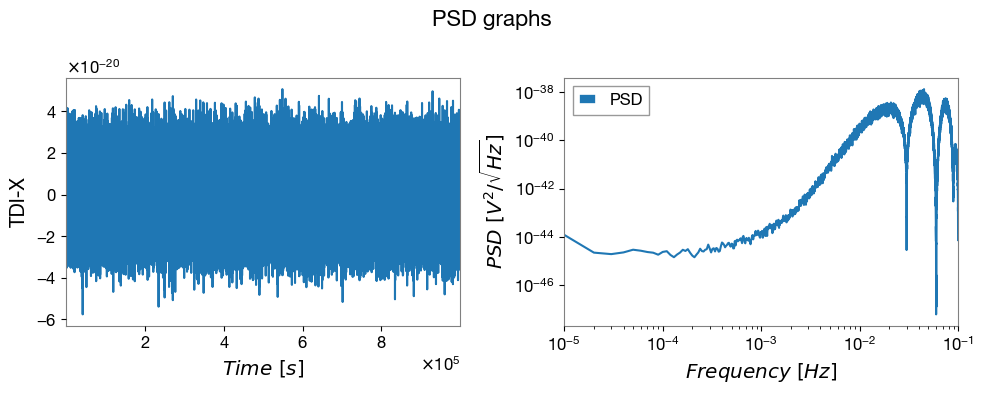

In [2]:
# 1) Read the TDI time series
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data_orig, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd, _, nseg = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg
) 

f_orig, orig_psd = scipy.signal.welch(
    x=data_orig,
    fs=fs,
    nperseg=nperseg
) 

plot(
    data=data_orig,
    t=t, 
    f=f_orig, 
    psd= [orig_psd],
    labels= ["PSD"],
    title="TDI-X", 
    bigtitle="PSD graphs",
    f_lims = [f_orig[1], (fs / 2.0)]
)

# 3) generate n time-domain noise realisations such that PSD equals "PSD OF TDI time series "
time_noises = n_time_noise_from_psd(
    orig_psd, 
    fs, 
    nperseg, 
    n=1000,
    seed_offset=0
)

In [3]:
# print(data.shape)
# print(t.shape)
# print(f_orig.shape)
# print(orig_psd.shape)
# print(1 + (200000 - 20000) // (20000 - 10000))
# # 1 + (len(x) - nperseg) // (nperseg - noverlap)
# print(nseg)

In [4]:
# print(nseg)

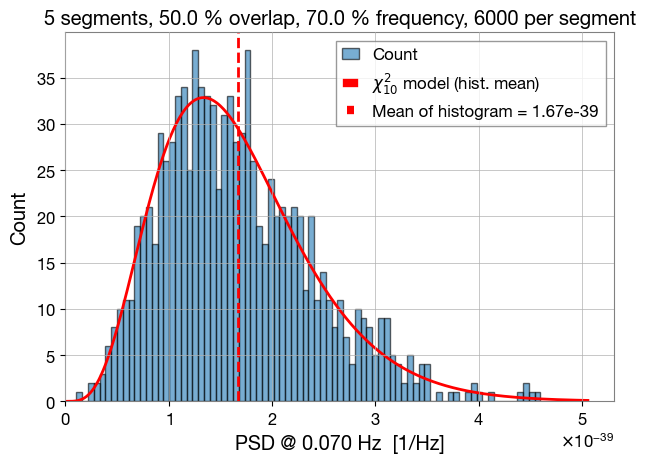

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


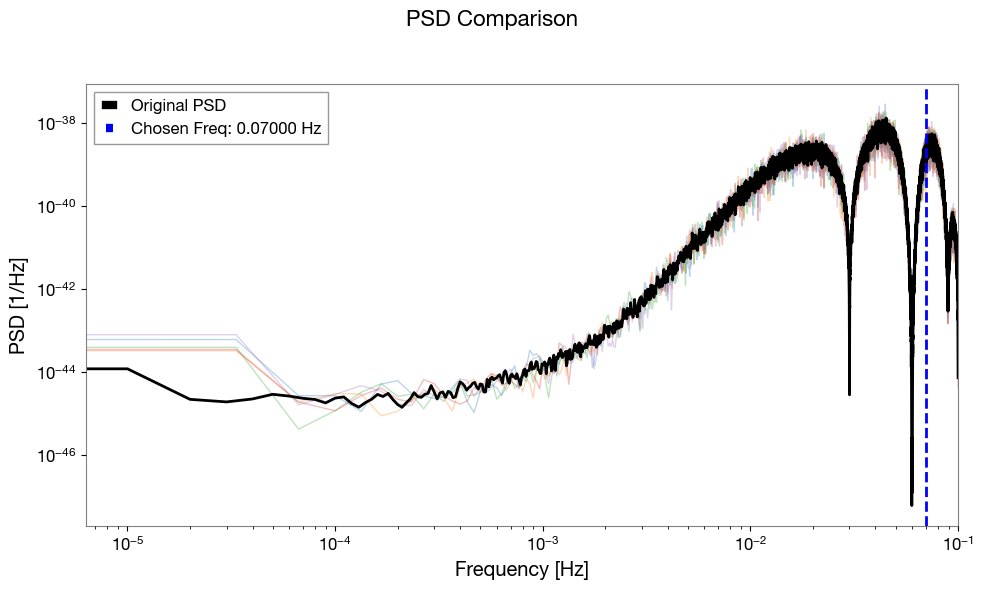

In [5]:
# 4) Find PSDs of time-domain noise realisations
nperseg_noise = 6000
noverlap= nperseg_noise // 2
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap= noverlap)

# 5) Choose a frequency
fraction=0.7
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

# 6) Plot the histogram
plot_psd_noise_histogram(
    psd_noise_vals,
    orig_psd_val,
    chosen_f_noise,
    n_bins=80,
    title=f"{nseg[0]} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    df=2*nseg[0],
    show_pdf = True,
    show_orig_pdf=False,
)

plot_orig_and_noise_psds(f_orig, orig_psd, chosen_f_orig, f_noise, noise_psds, chosen_f_noise, n=5, alpha=0.3, bigtitle="PSD Comparison")

                                  
# plot_psd_bias(f_noise, residual, mark_freq=0.08)

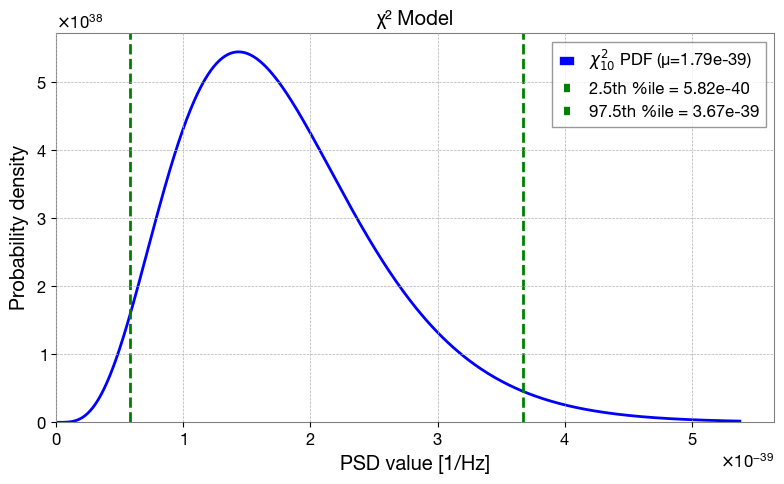

In [6]:
draw_chi2(μ=orig_psd_val, df=10, show_percentile=95)

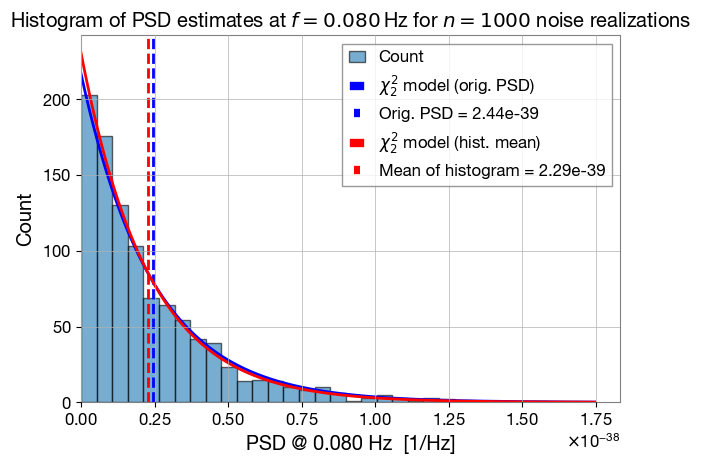

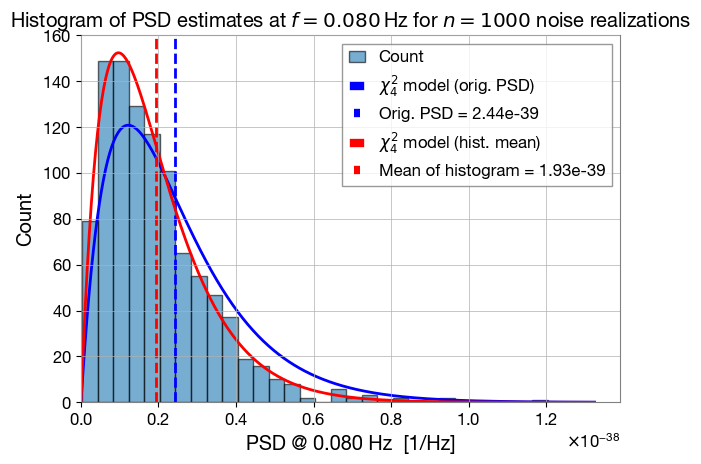

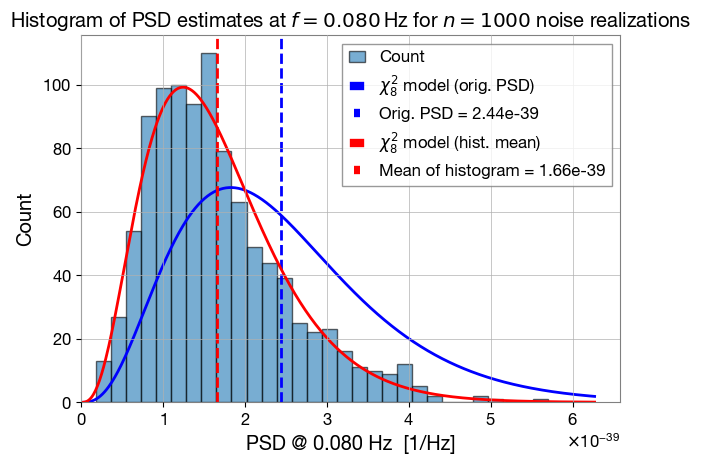

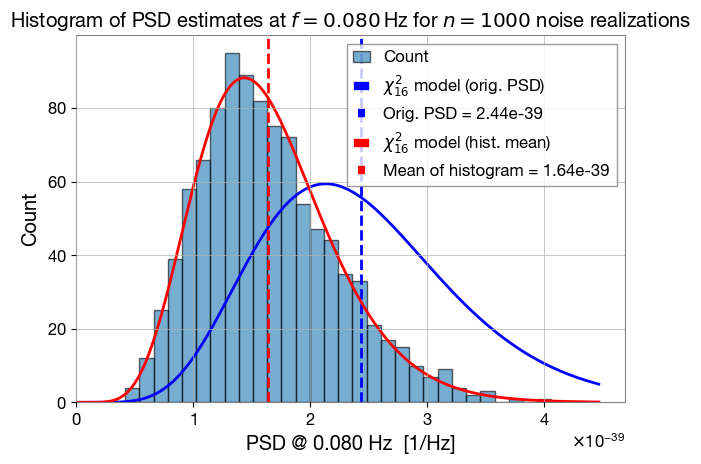

In [9]:
nperseg_noise = 20000
f_orig, orig_psd, _, nseg = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg
) 

noverlap = 0
fraction = 0.8
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(
    psd_noise_vals,
    orig_psd_val,
    chosen_f_noise,
    df=2*nseg[0],
    n_bins=30,
    title=(
      fr"Histogram of PSD estimates at $f={chosen_f_noise:.3f}\,$Hz "
      fr"for $n={len(psd_noise_vals)}$ noise realizations"
    )
)

nperseg_noise = 10000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(
    psd_noise_vals,
    orig_psd_val,
    chosen_f_noise,
    df=2*nseg[0],
    n_bins=30,
    title=(
      fr"Histogram of PSD estimates at $f={chosen_f_noise:.3f}\,$Hz "
      fr"for $n={len(psd_noise_vals)}$ noise realizations"
    )
)

nperseg_noise = 5000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(
    psd_noise_vals,
    orig_psd_val,
    chosen_f_noise,
    df=2*nseg[0],
    n_bins=30,
    title=(
      fr"Histogram of PSD estimates at $f={chosen_f_noise:.3f}\,$Hz "
      fr"for $n={len(psd_noise_vals)}$ noise realizations"
    )
)

nperseg_noise = 2500
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(
    psd_noise_vals,
    orig_psd_val,
    chosen_f_noise,
    df=2*nseg[0],
    n_bins=30,
    title=(
      fr"Histogram of PSD estimates at $f={chosen_f_noise:.3f}\,$Hz "
      fr"for $n={len(psd_noise_vals)}$ noise realizations"
    )
)

chosen f_noise: 0.08
chosen f_orig: 0.08


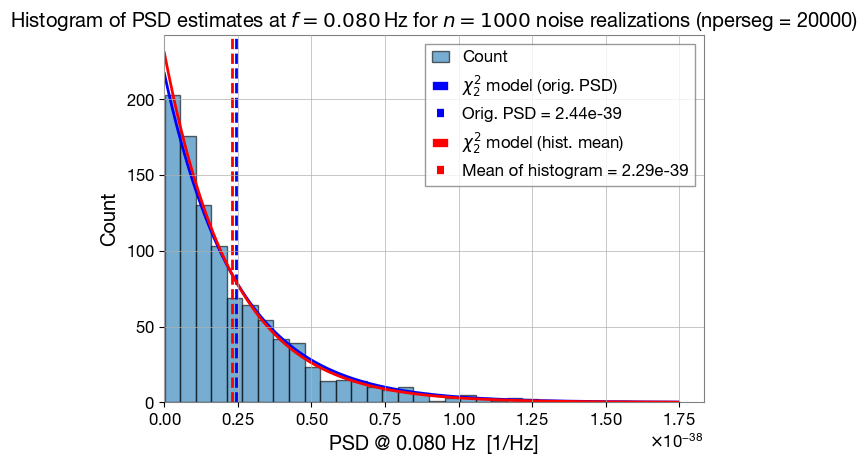

chosen f_noise: 0.08
chosen f_orig: 0.08


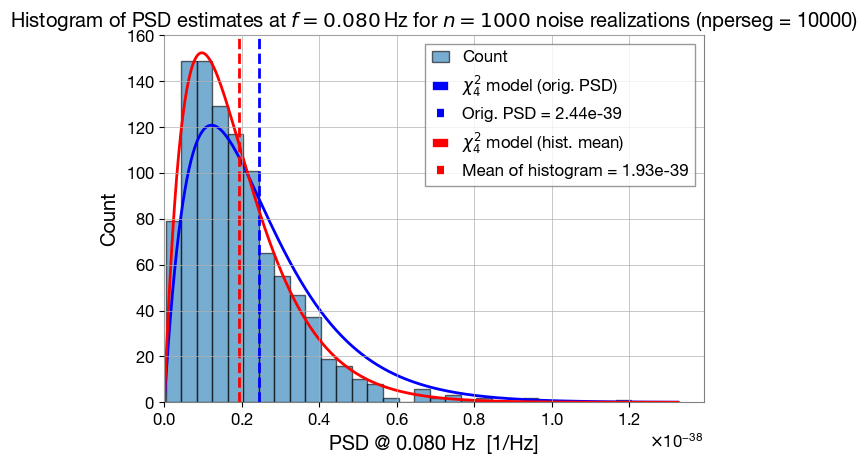

chosen f_noise: 0.08
chosen f_orig: 0.08


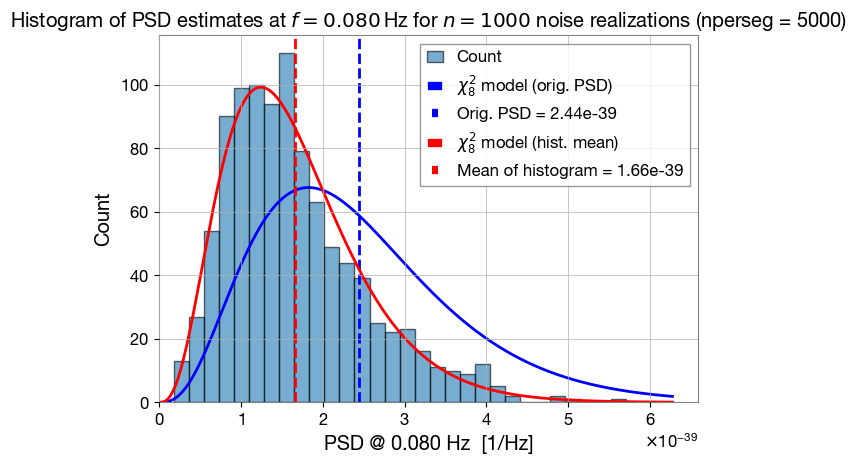

chosen f_noise: 0.08
chosen f_orig: 0.08


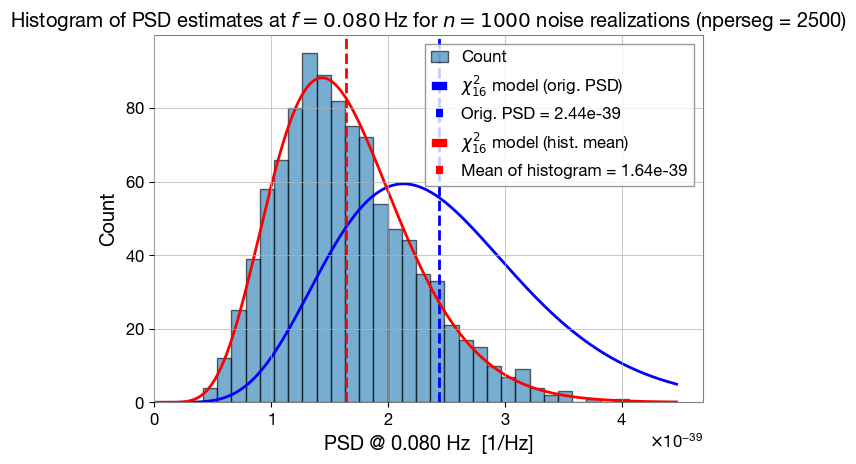

In [37]:
nperseg=20000
f_orig, orig_psd, _, nseg = wosa(
        x=data_orig,
        fs=fs,
        nperseg=nperseg
)
# --- parameters that stay the same ---
noverlap  = 0
fraction  = 0.8
nperseg_list = [20_000, 10_000, 5_000, 2_500]

# --- run the four cases ---
for nperseg in nperseg_list:
    # noise-realisation PSDs
    f_noise, noise_psds, nseg = n_noise_psds(
        time_noises, fs, nperseg, noverlap=noverlap
    )

    # pull out the values around the chosen frequency bin
    psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(
        orig_psd, f_orig, noise_psds, f_noise, fraction=fraction
    )

    print(f"chosen f_noise: {chosen_f_noise}")
    print(f"chosen f_orig: {chosen_f_orig}")

    # χ² d.o.f. is 2 × (number of statistically independent segments)
    df = 2 * nseg[0]

    # plot
    plot_psd_noise_histogram(
        psd_noise_vals,
        orig_psd_val,
        chosen_f_noise,
        df=df,
        n_bins=30,
        title=(
            fr"Histogram of PSD estimates at $f={chosen_f_noise:.3f}\,$Hz "
            fr"for $n={len(psd_noise_vals)}$ noise realizations "
            fr"(nperseg = {nperseg})"
        ),
    )


chosen f_noise: 0.08
chosen f_orig: 0.08


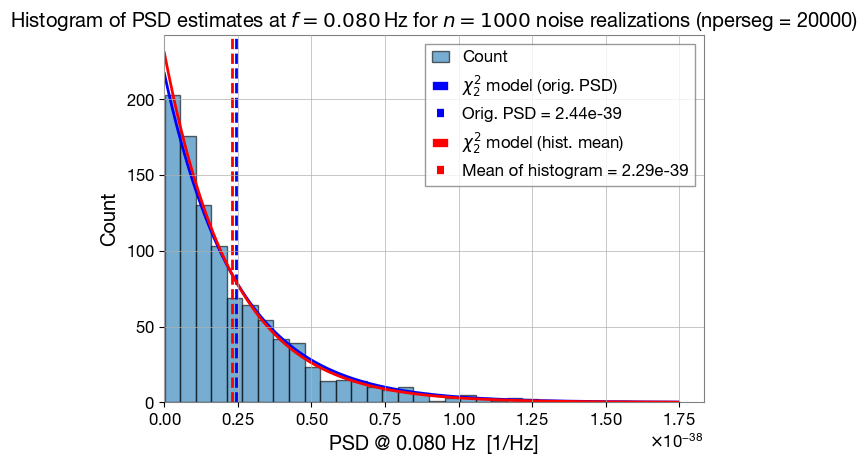

chosen f_noise: 0.08
chosen f_orig: 0.08


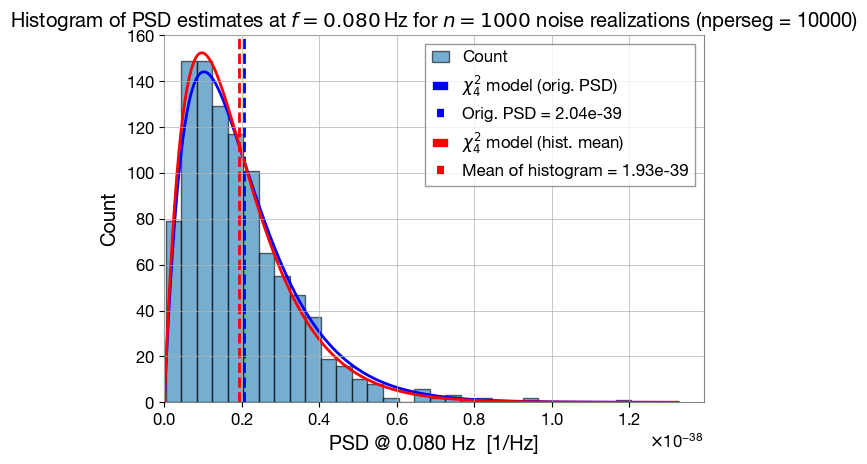

chosen f_noise: 0.08
chosen f_orig: 0.08


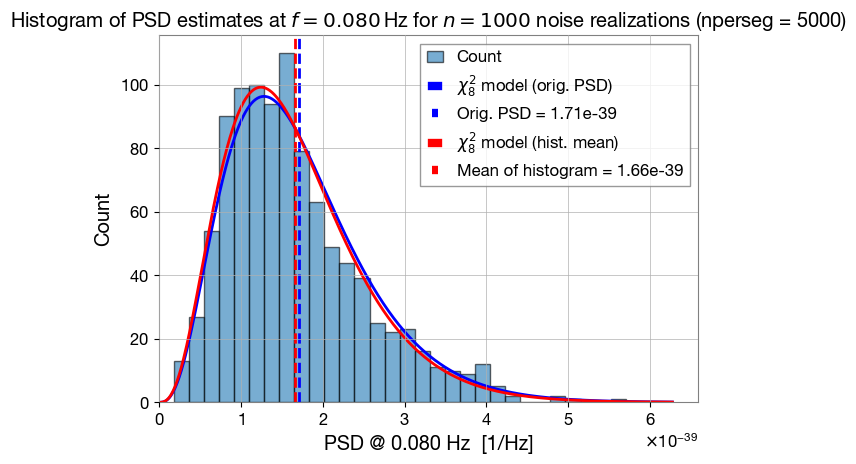

chosen f_noise: 0.08
chosen f_orig: 0.08


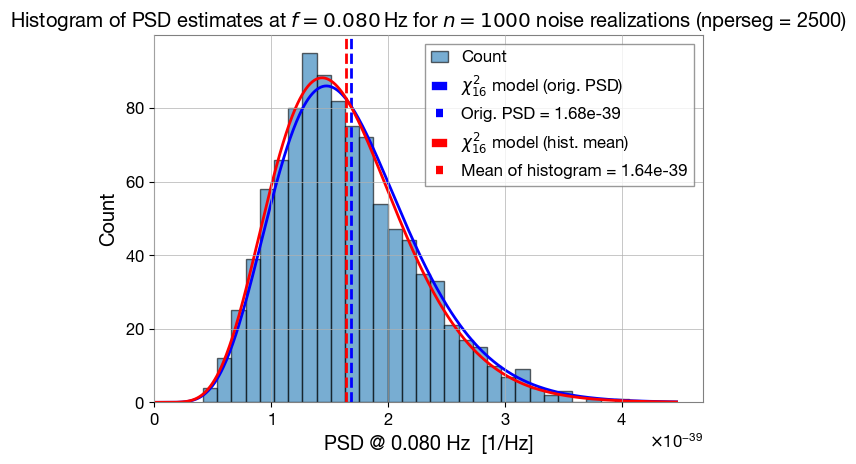

In [38]:
# --- parameters that stay the same ---
noverlap  = 0
fraction  = 0.8
nperseg_list = [20_000, 10_000, 5_000, 2_500]

# --- run the four cases ---
for nperseg in nperseg_list:
    # reference PSD (same nperseg)
    f_orig, orig_psd, _, nseg = wosa(
        x=data_orig,
        fs=fs,
        nperseg=nperseg
    )

    # noise-realisation PSDs
    f_noise, noise_psds, nseg = n_noise_psds(
        time_noises, fs, nperseg, noverlap=noverlap
    )

    # pull out the values around the chosen frequency bin
    psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(
        orig_psd, f_orig, noise_psds, f_noise, fraction=fraction
    )

    print(f"chosen f_noise: {chosen_f_noise}")
    print(f"chosen f_orig: {chosen_f_orig}")

    # χ² d.o.f. is 2 × (number of statistically independent segments)
    df = 2 * nseg[0]

    # plot
    plot_psd_noise_histogram(
        psd_noise_vals,
        orig_psd_val,
        chosen_f_noise,
        df=df,
        n_bins=30,
        title=(
            fr"Histogram of PSD estimates at $f={chosen_f_noise:.3f}\,$Hz "
            fr"for $n={len(psd_noise_vals)}$ noise realizations "
            fr"(nperseg = {nperseg})"
        ),
    )


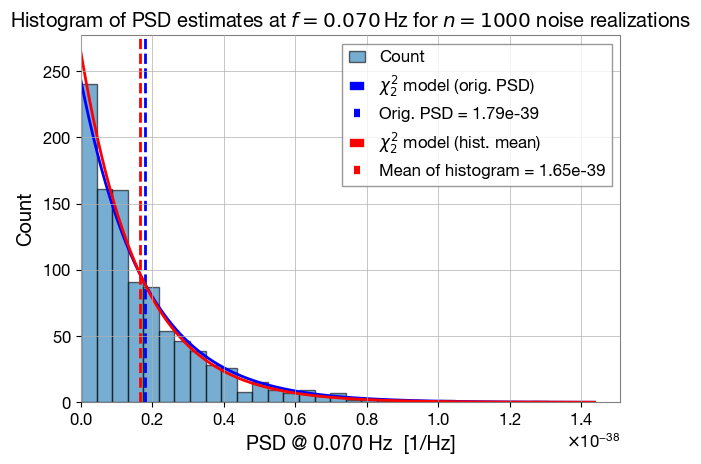

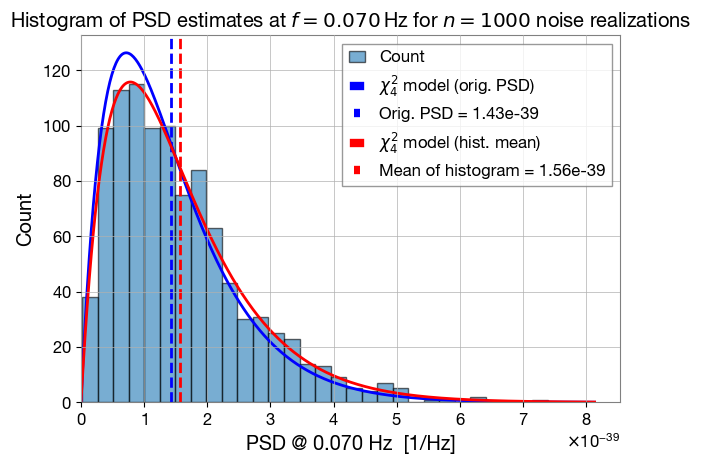

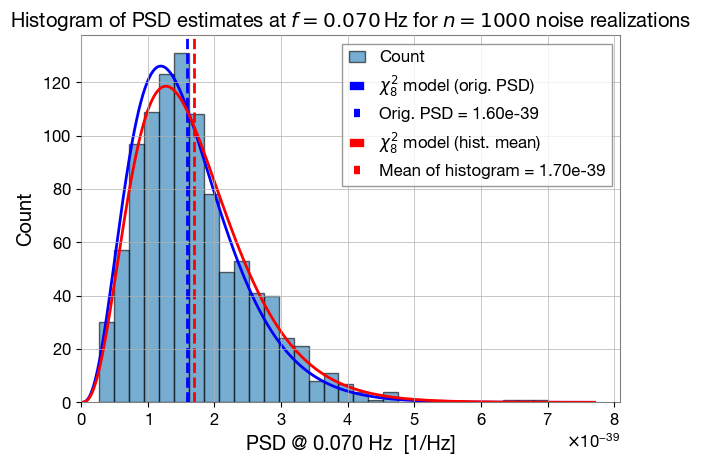

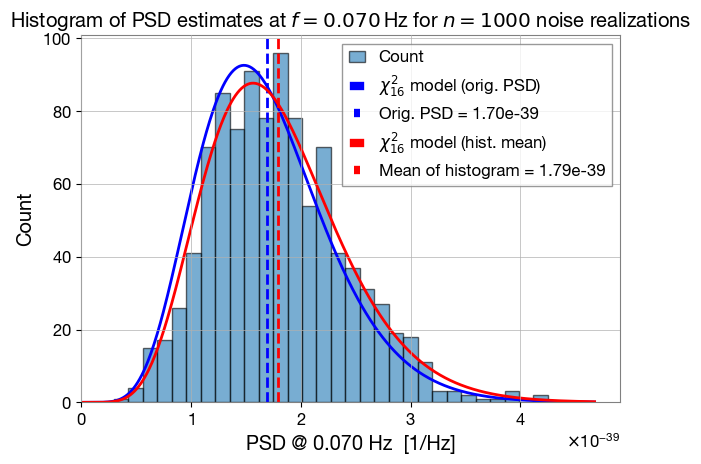

In [28]:
# --- parameters that stay the same ---
noverlap  = 0
fraction  = 0.7
nperseg_list = [20_000, 10_000, 5_000, 2_500]

# --- run the four cases ---
for nperseg in nperseg_list:
    # reference PSD (same nperseg)
    f_orig, orig_psd, _, nseg = wosa(
        x=data_orig,
        fs=fs,
        nperseg=nperseg
    )

    # noise-realisation PSDs
    f_noise, noise_psds, nseg = n_noise_psds(
        time_noises, fs, nperseg, noverlap=noverlap
    )

    # pull out the values around the chosen frequency bin
    psd_noise_vals, orig_psd_val, chosen_f_noise, _ = compute_psd_noise_distribution(
        orig_psd, f_orig, noise_psds, f_noise, fraction=fraction
    )

    # χ² d.o.f. is 2 × (number of statistically independent segments)
    df = 2 * nseg[0]

    # plot
    plot_psd_noise_histogram(
        psd_noise_vals,
        orig_psd_val,
        chosen_f_noise,
        df=df,
        n_bins=30,
        title=(
            fr"Histogram of PSD estimates at $f={chosen_f_noise:.3f}\,$Hz "
            fr"for $n={len(psd_noise_vals)}$ noise realizations "
            fr"(nperseg = {nperseg})"
        ),
    )


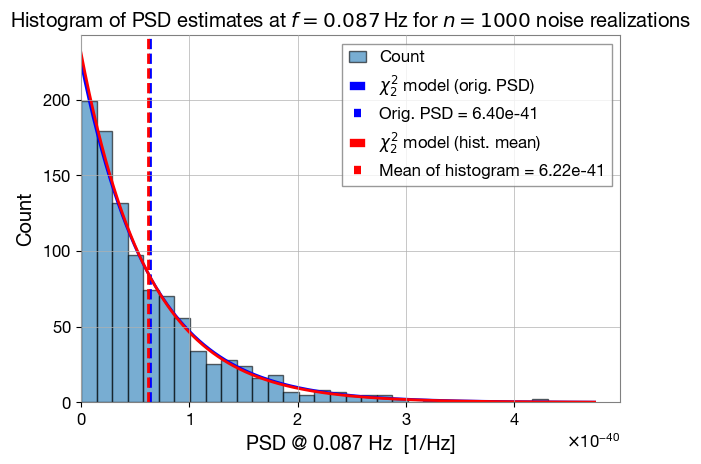

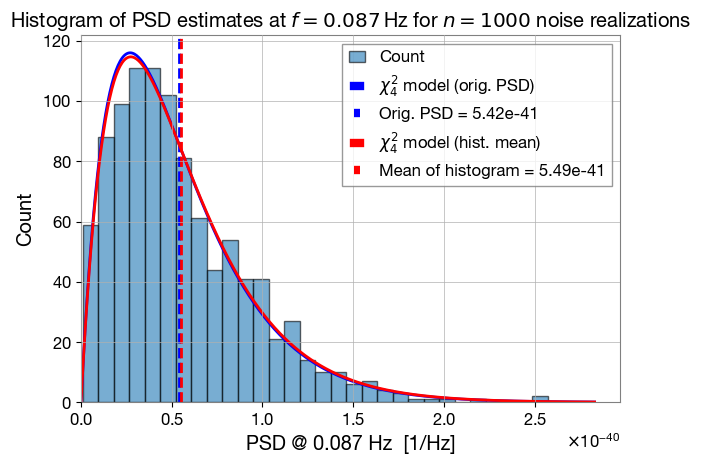

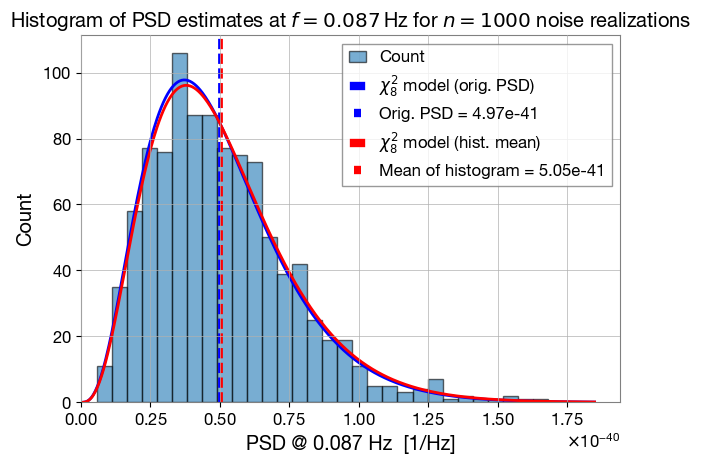

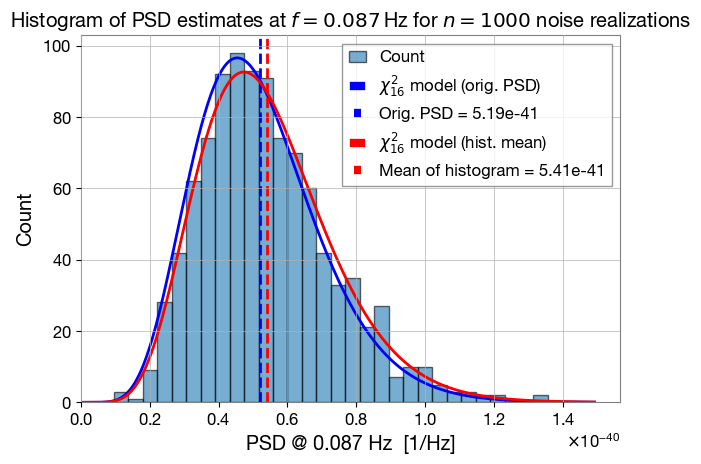

In [34]:
noverlap = 0
fraction = 0.87

nperseg = 20000
f_orig, orig_psd, _, nseg = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg
) 
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(
    psd_noise_vals,
    orig_psd_val,
    chosen_f_noise,
    df=2*nseg[0],
    n_bins=30,
    title=(
      fr"Histogram of PSD estimates at $f={chosen_f_noise:.3f}\,$Hz "
      fr"for $n={len(psd_noise_vals)}$ noise realizations"
    )
)

nperseg = 10000
f_orig, orig_psd, _, nseg = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg
) 
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(
    psd_noise_vals,
    orig_psd_val,
    chosen_f_noise,
    df=2*nseg[0],
    n_bins=30,
    title=(
      fr"Histogram of PSD estimates at $f={chosen_f_noise:.3f}\,$Hz "
      fr"for $n={len(psd_noise_vals)}$ noise realizations"
    )
)

nperseg = 5000
f_orig, orig_psd, _, nseg = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg
) 
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(
    psd_noise_vals,
    orig_psd_val,
    chosen_f_noise,
    df=2*nseg[0],
    n_bins=30,
    title=(
      fr"Histogram of PSD estimates at $f={chosen_f_noise:.3f}\,$Hz "
      fr"for $n={len(psd_noise_vals)}$ noise realizations"
    )
)

nperseg = 2500
f_orig, orig_psd, _, nseg = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg
) 
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(
    psd_noise_vals,
    orig_psd_val,
    chosen_f_noise,
    df=2*nseg[0],
    n_bins=30,
    title=(
      fr"Histogram of PSD estimates at $f={chosen_f_noise:.3f}\,$Hz "
      fr"for $n={len(psd_noise_vals)}$ noise realizations"
    )
)

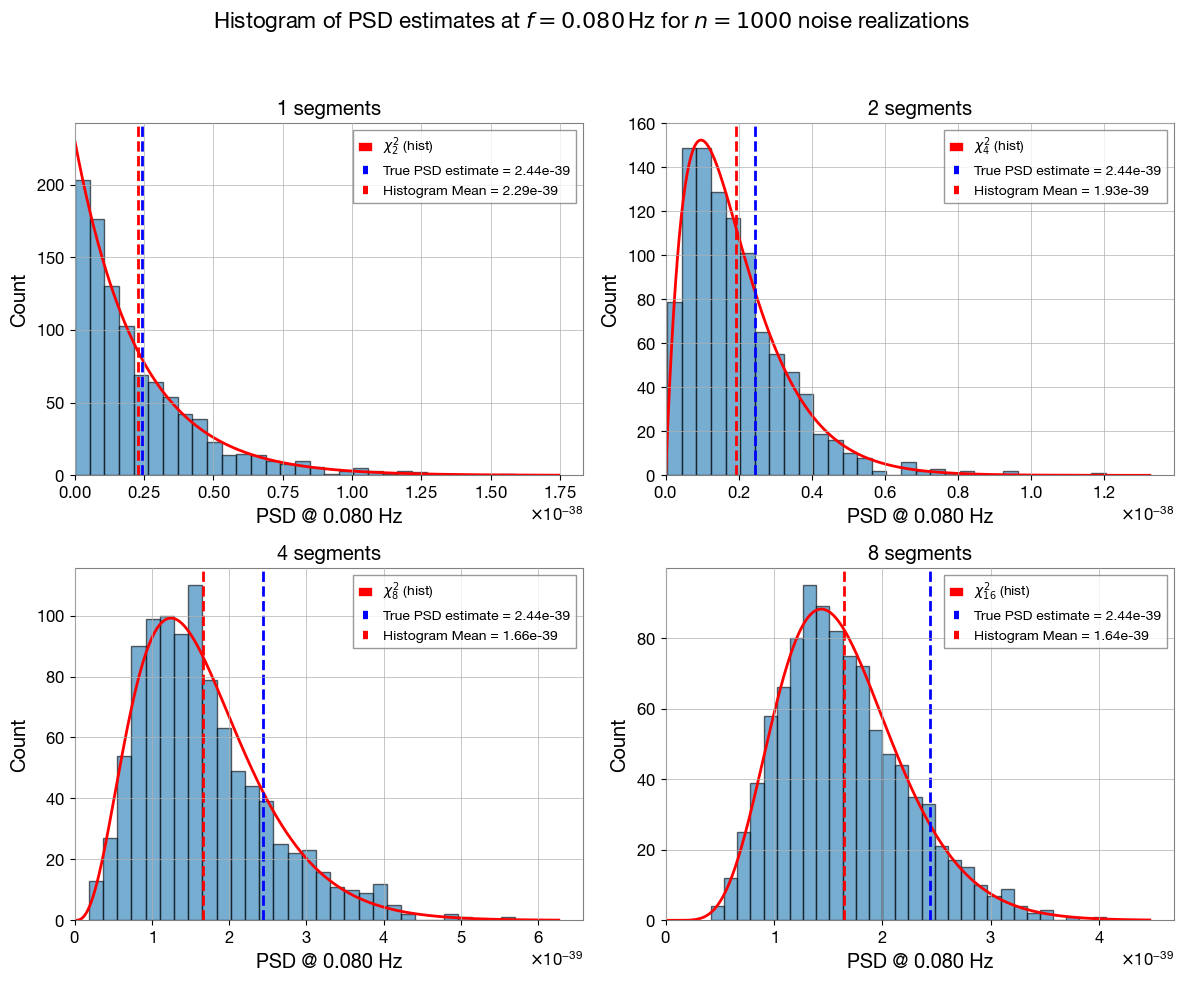

In [27]:
nperseg=20000
f_orig, orig_psd, _, nseg = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg
) 
fraction=0.8
noverlap = 0
# 1) choose your segment-sizes:
nperseg_list = [20000, 10000, 5000, 2500]
noise_vals_list = []
orig_psd_list   = []
freq_list       = []
df_list         = []
seg_counts      = []

for nperseg in nperseg_list:
    f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg, noverlap=noverlap)
    psd_vals, orig_val, chosen_freq, _ = compute_psd_noise_distribution(
        orig_psd, f_orig, noise_psds, f_noise, fraction=fraction
    )
    noise_vals_list.append(psd_vals)
    orig_psd_list.append(orig_val)
    freq_list.append(chosen_freq)
    df_list.append(2 * nseg[0])
    seg_counts.append(nseg[0])

main_title = (
    fr"Histogram of PSD estimates at $f={chosen_freq:.3f}\,$Hz "
    fr"for $n={len(noise_vals_list[0])}$ noise realizations"
)

plot_psd_noise_histogram_two_cross_two(
    noise_vals_list,
    orig_psd_list,
    freq_list,
    df_list,
    seg_counts,
    main_title,
    n_bins=30,
    show_biased_hist=False
)


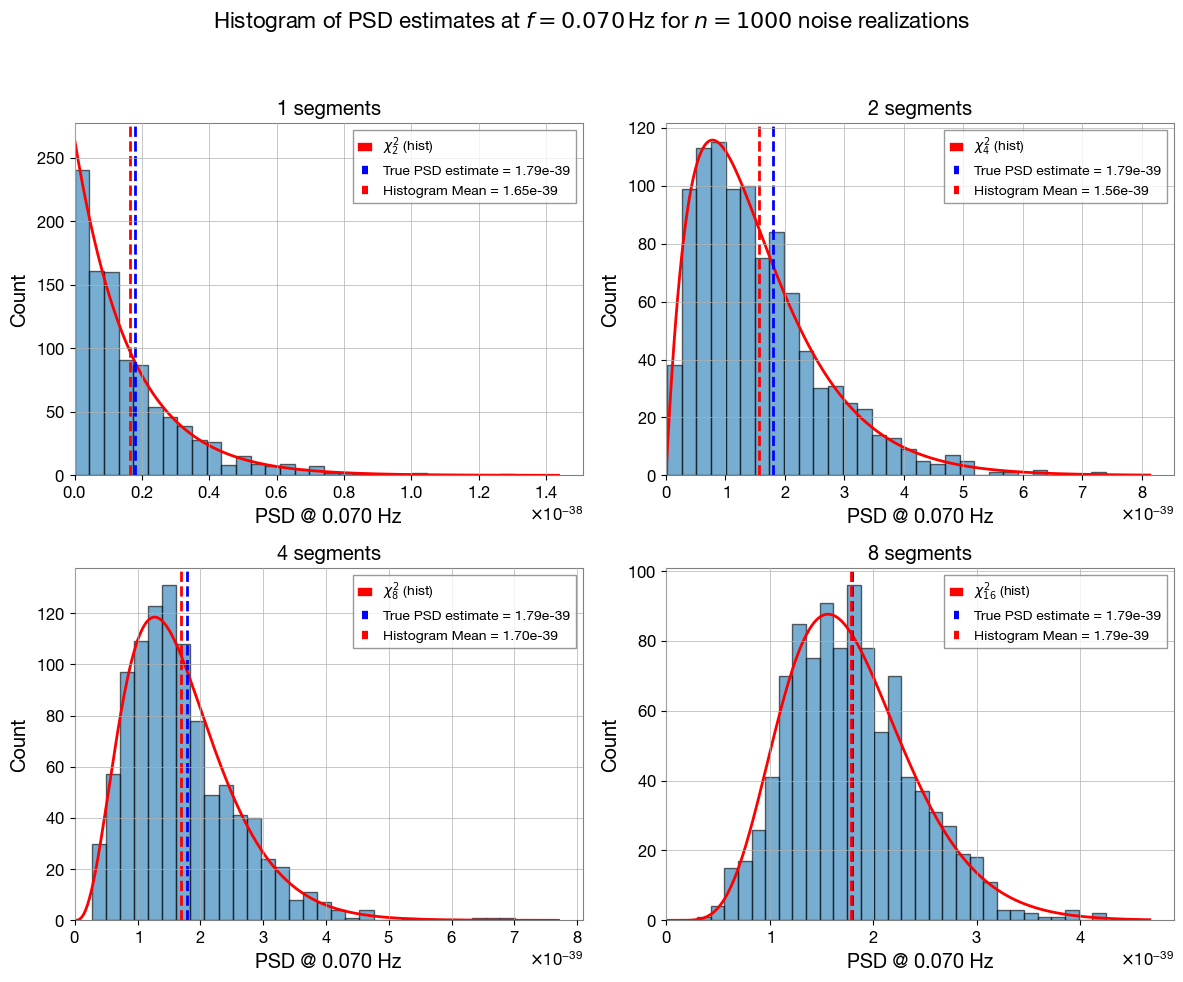

[0.07, 0.07, 0.07, 0.07]


In [12]:
fraction=0.7
# 1) choose your segment-sizes:
nperseg_list = [20000, 10000, 5000, 2500]
noise_vals_list = []
orig_psd_list   = []
freq_list       = []
df_list         = []
seg_counts      = []

for nperseg in nperseg_list:
    f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg, noverlap=noverlap)
    psd_vals, orig_val, chosen_freq, _ = compute_psd_noise_distribution(
        orig_psd, f_orig, noise_psds, f_noise, fraction=fraction
    )
    noise_vals_list.append(psd_vals)
    orig_psd_list.append(orig_val)
    freq_list.append(chosen_freq)
    df_list.append(2 * nseg[0])
    seg_counts.append(nseg[0])

main_title = (
    fr"Histogram of PSD estimates at $f={chosen_freq:.3f}\,$Hz "
    fr"for $n={len(noise_vals_list[0])}$ noise realizations"
)

plot_psd_noise_histogram_two_cross_two(
    noise_vals_list,
    orig_psd_list,
    freq_list,
    df_list,
    seg_counts,
    main_title,
    n_bins=30,
    show_biased_hist=False
)

print(freq_list)

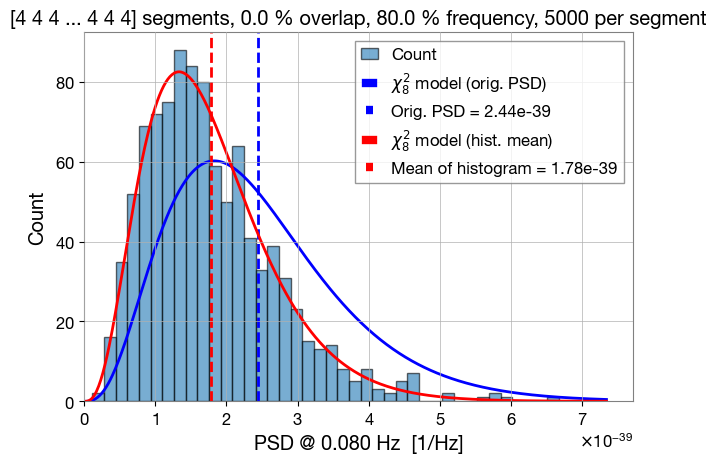

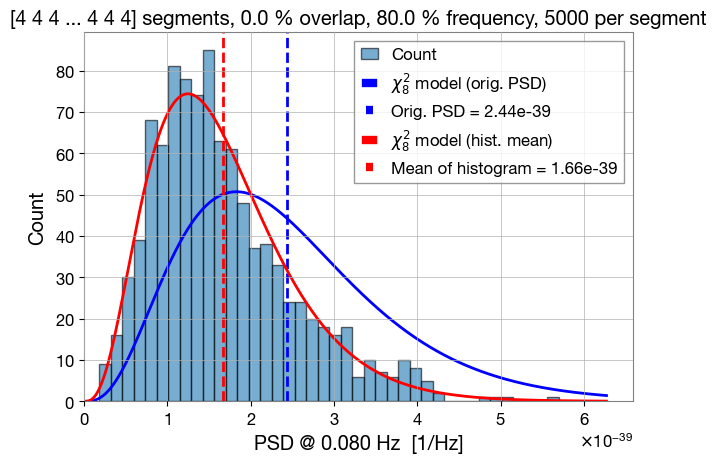

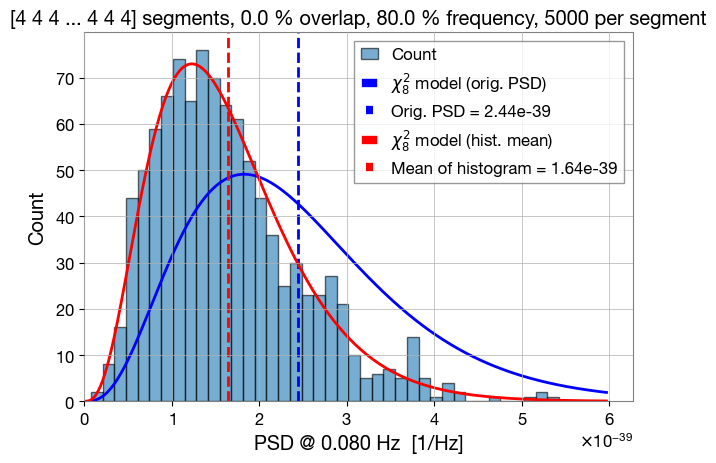

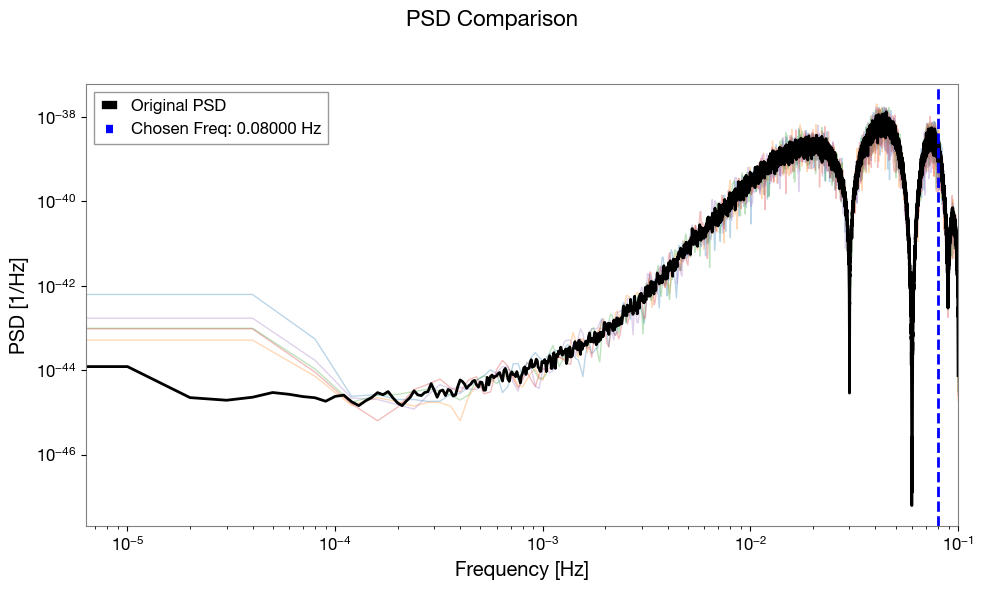

In [13]:
nperseg_noise = 5000
noverlap = 0
fraction = 0.8

f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, window='boxcar')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=40,  
    df=2*nseg[0]
)

f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, window='hann')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=40,  
    df=2*nseg[0]
)

f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, window='blackmanharris')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=40,  
    df=2*nseg[0]
)

plot_orig_and_noise_psds(f_orig, orig_psd, chosen_f_orig, f_noise, noise_psds, chosen_f_noise, n=5, alpha=0.3, bigtitle="PSD Comparison")

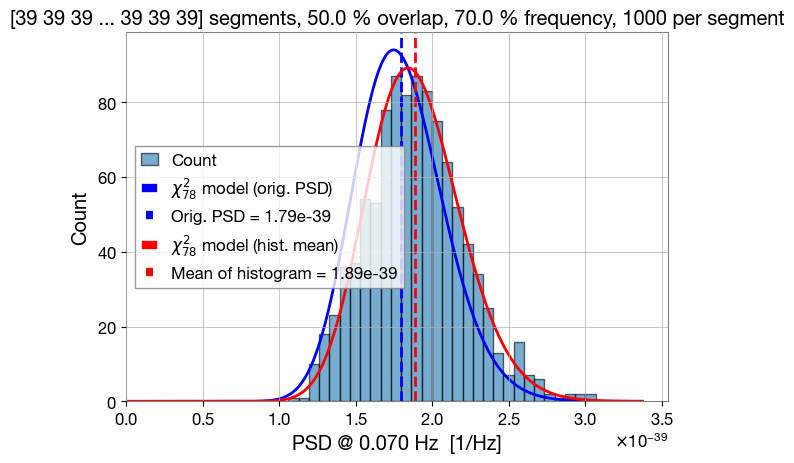

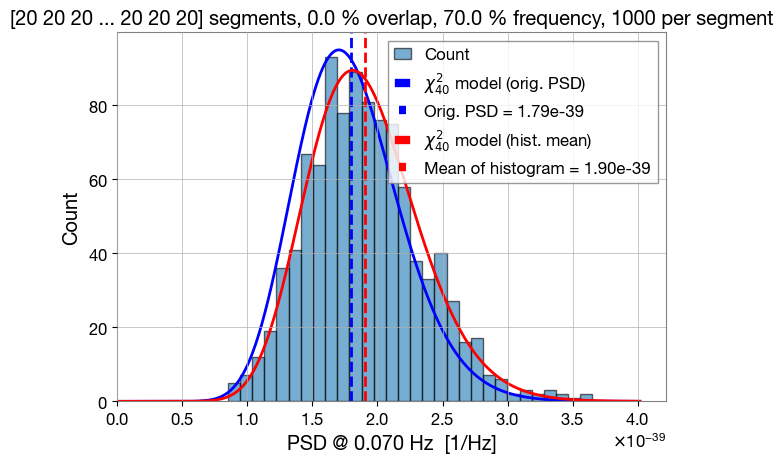

In [14]:
nperseg_noise = 1000
noverlap = nperseg_noise // 2
fraction = 0.7
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=30,  
    df= 2*nseg[0]
)

noverlap = 0
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=30,  
    df= 2*nseg[0]
)

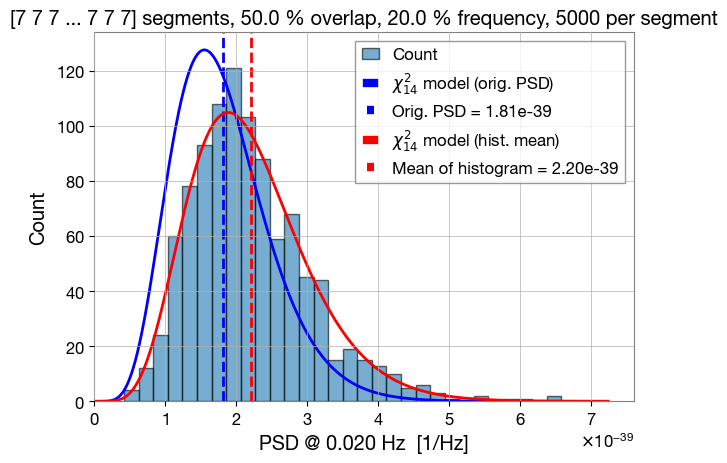

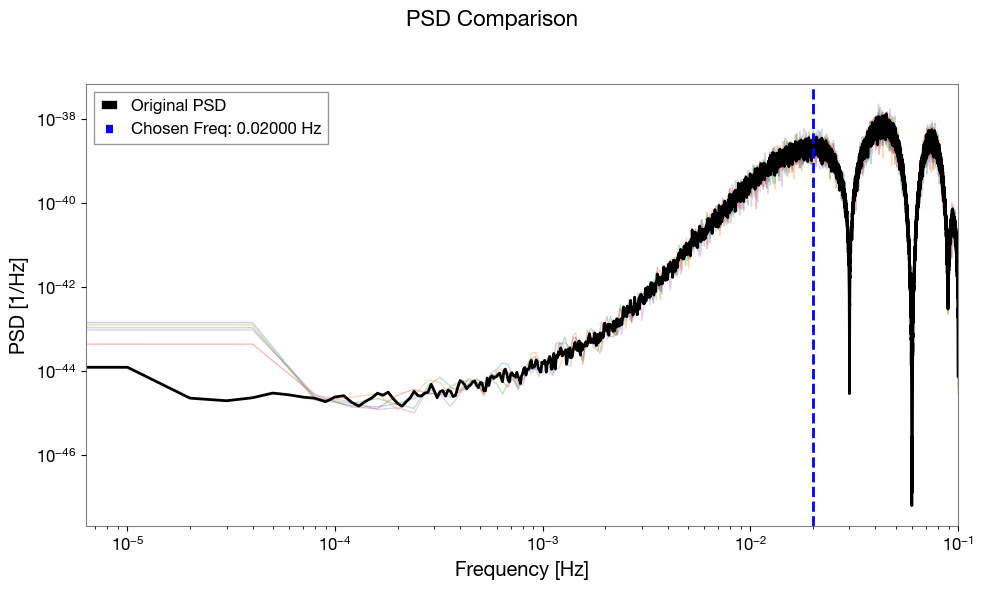

In [15]:
nperseg_noise = 5000
noverlap = nperseg_noise // 2
fraction = 0.2
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=30,  
    df=2*nseg[0]
)

plot_orig_and_noise_psds(
    f_orig,
    orig_psd,
    chosen_f_orig,
    f_noise,
    noise_psds,
    chosen_f_noise,
    n=5,
    alpha=0.3,
    bigtitle="PSD Comparison"
)

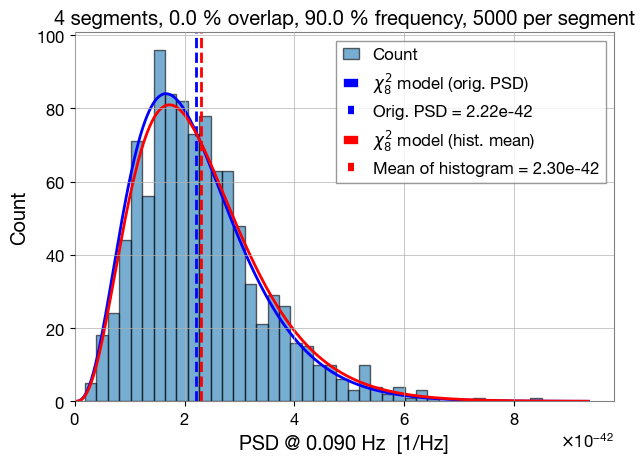

In [16]:
nperseg_noise = 5000
noverlap = 0
fraction = 0.9
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg[0]} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=40,  
    df=8
)

# psdAndEverything(
#     nperseg_noise = 5000, 
#     noverlap = 0, 
#     fraction = fraction, 
#     df = 9,
#     n_bins = 40
# )

# psdAndEverything(
#     nperseg_noise = 5000, 
#     noverlap = 0, 
#     fraction = fraction, 
#     df = 7,
#     n_bins = 40
# )

# psdAndEverything(
#     nperseg_noise = 5000, 
#     noverlap = 0, 
#     fraction = fraction, 
#     df = 6,
#     n_bins = 40
# )

# psdAndEverything(
#     nperseg_noise = 5000, 
#     noverlap = 0, 
#     fraction = fraction, 
#     df = 5,
#     n_bins = 40
# )

# plot_orig_and_noise_psds(f_orig, orig_psd, chosen_f_orig, f_noise, noise_psds, chosen_f_noise, n=5, alpha=0.3, bigtitle="PSD Comparison")

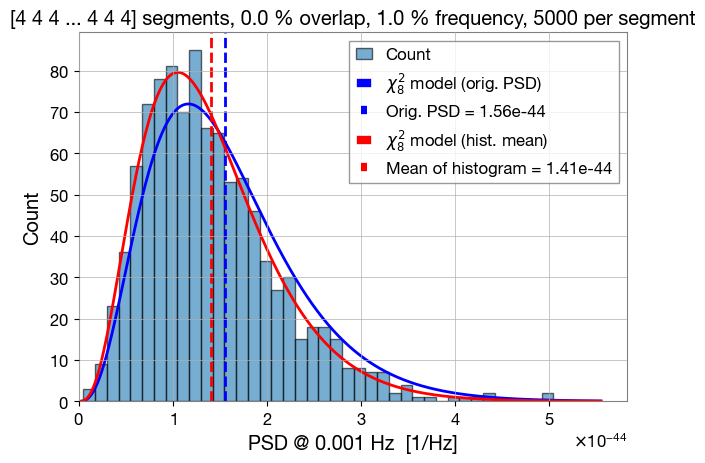

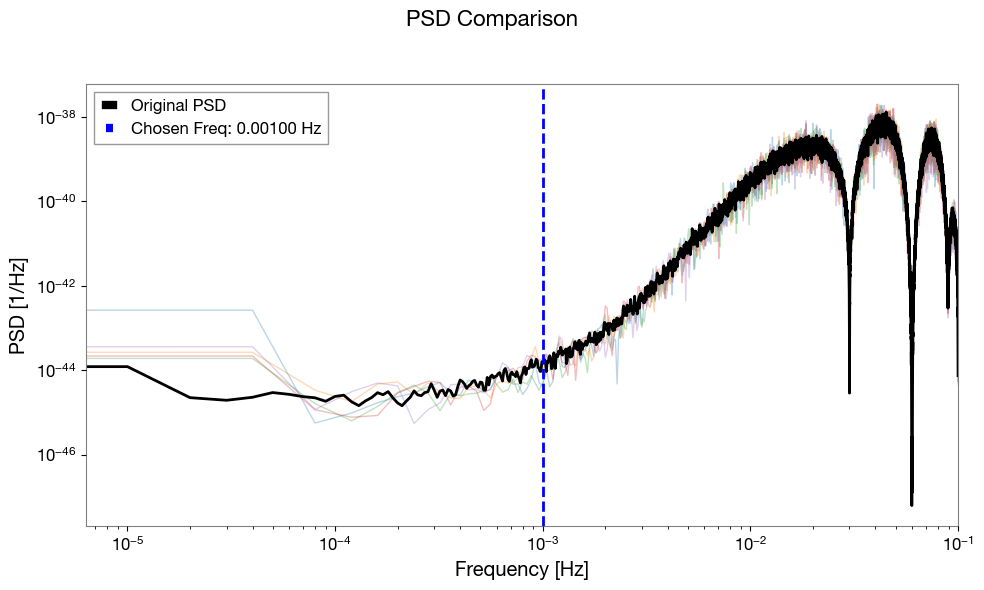

In [17]:
nperseg_noise = 5000
noverlap = 0
fraction = 0.01
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(
    psd_noise_vals, 
    orig_psd_val, 
    chosen_f_noise, 
    title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=40,  
    df=8
)

plot_orig_and_noise_psds(f_orig, orig_psd, chosen_f_orig, f_noise, noise_psds, chosen_f_noise, n=5, alpha=0.3, bigtitle="PSD Comparison")

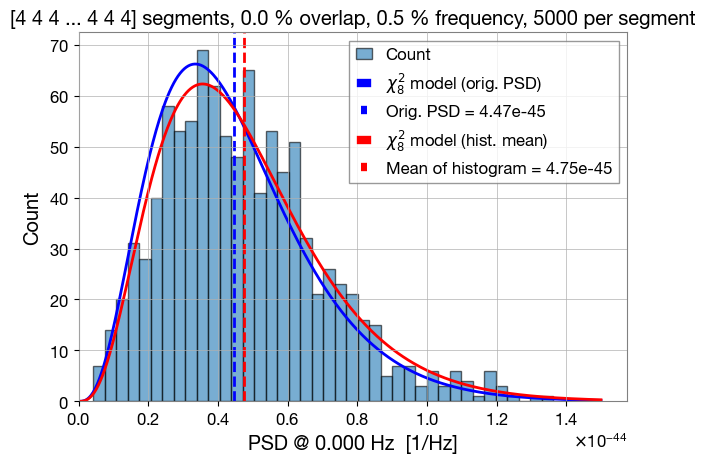

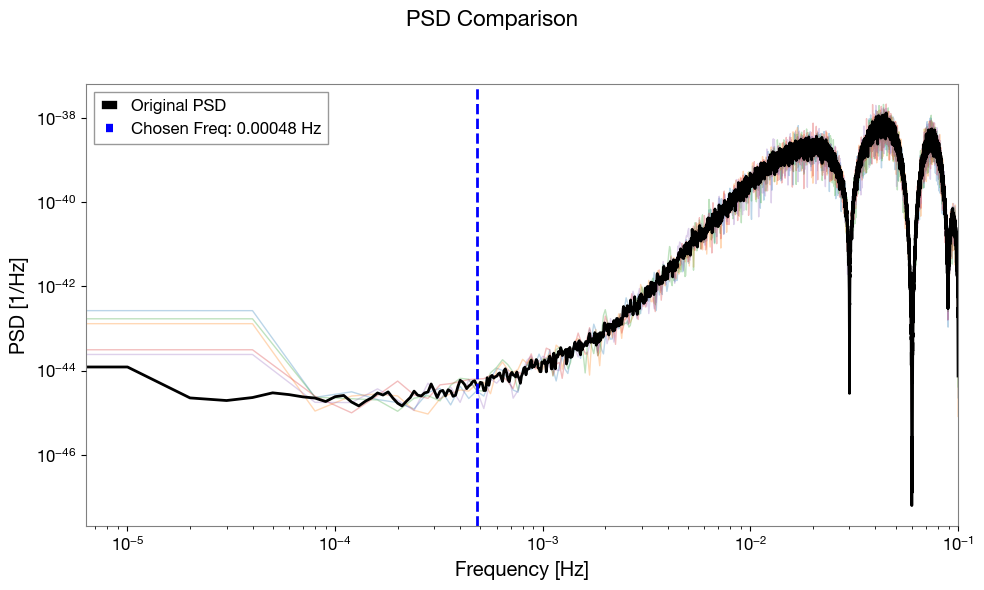

0.00048000000000000007
[4 4 4 ... 4 4 4]


In [18]:
nperseg_noise = 5000
noverlap = 0
fraction = 0.005
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=40,  
    df=8
)

plot_orig_and_noise_psds(f_orig, orig_psd, chosen_f_orig, f_noise, noise_psds, chosen_f_noise, n=5, alpha=0.3, bigtitle="PSD Comparison")

print(chosen_f_noise)
print(nseg)

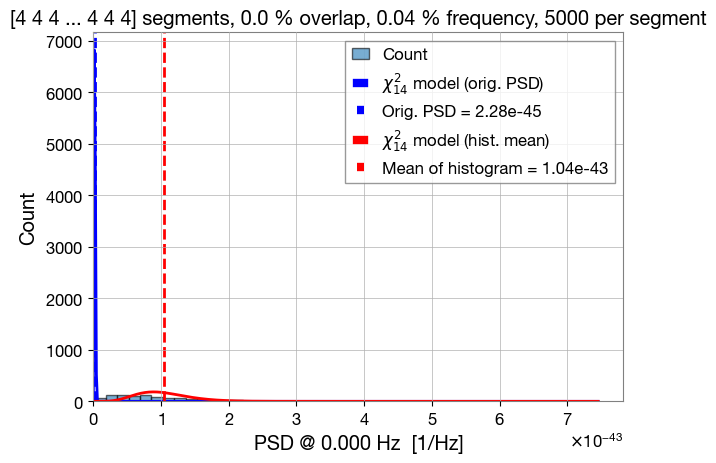

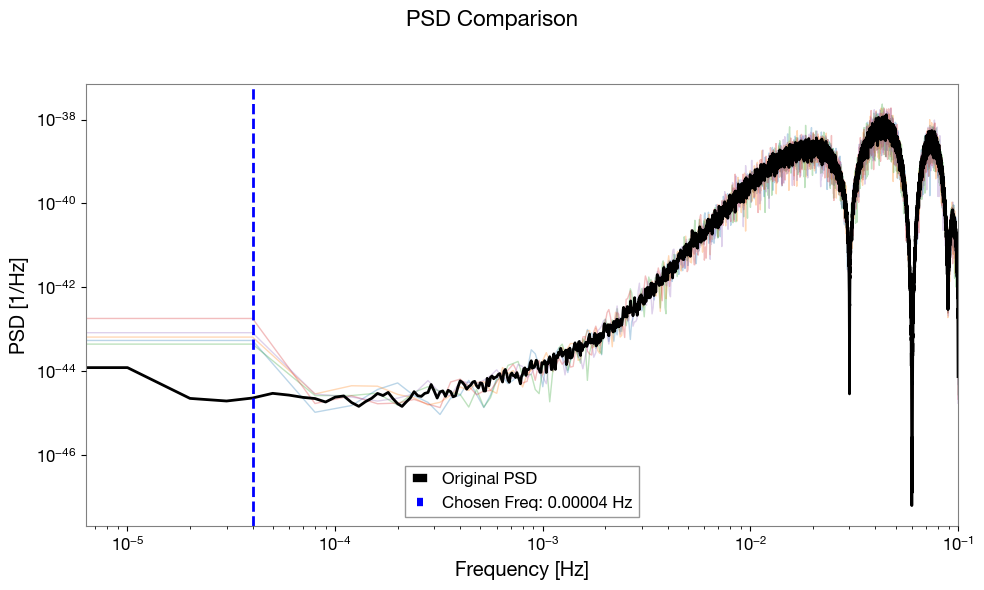

In [19]:
nperseg_noise = 5000
noverlap = 0
fraction = 0.0004
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=40,  
    df=14
)

plot_orig_and_noise_psds(f_orig, orig_psd, chosen_f_orig, f_noise, noise_psds, chosen_f_noise, n=5, alpha=0.3, bigtitle="PSD Comparison")

In [20]:
# Optionally, use estimators 
# df_est, _ = mle_df(psd_noise_vals, mu=orig_psd_val, round_even=False)
# plot_psd_noise_histogram(
#     psd_noise_vals,
#     orig_psd_val,
#     chosen_f_noise,
#     n_bins=30,
#     title="Noise PSD distribution", 
#     df=df_est
# )

# df_est = 2 * psd_noise_vals.mean()**2 / psd_noise_vals.var(ddof=1)
# plot_psd_noise_histogram(
#     psd_noise_vals,
#     orig_psd_val,
#     chosen_f_noise,
#     n_bins=30,
#     title="Noise PSD distribution", 
#     df=df_est
# )

# df_est = int(round((2*psd_noise_vals.mean()**2 / psd_noise_vals.var(ddof=1))/2.0))*2
# plot_psd_noise_histogram(
#     psd_noise_vals,
#     orig_psd_val,
#     chosen_f_noise,
#     n_bins=30,
#     title="Noise PSD distribution", 
#     df=df_est
# )

# Optionally, plot which freq bin you have chosen
# plot_orig_and_noise_psds(
#     f_orig,
#     orig_psd,
#     chosen_f_orig,
#     f_noise,
#     noise_psds,
#     chosen_f_noise,
#     n=5,
#     alpha=0.3,
#     bigtitle="PSD Comparison"
# )